# 99 — Cross-Factor × Cross-Market Summary

Consolidates notebooks 01 (monthly 12-1 momentum) and 02 (weekly 1-week
reversal) across US S&P 500, TW 0050, and Crypto top 30 USDT.

**Questions this notebook answers:**
1. Which (factor, market) combinations are viable net of costs?
2. Are momentum and reversal genuinely independent (low return correlation)?
3. Does combining them give a better Sharpe than either alone?
4. How stable is each strategy — rolling 1-year Sharpe?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qtools.backtest.costs import CRYPTO, TW_EQUITY, US_EQUITY, CostModel
from qtools.backtest.engine import BacktestEngine
from qtools.backtest.portfolio import signal_to_weights
from qtools.data.loaders.crypto import get_crypto_prices, get_top_pairs
from qtools.data.loaders.twse import get_tw50_constituents, get_tw_prices
from qtools.data.loaders.us import get_sp500_constituents, get_us_prices
from qtools.metrics.performance import annualized_return, max_drawdown, sharpe

from factors import momentum, short_term_reversal

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
START, END = "2015-01-01", "2025-07-31"

## 1. Load data and run all six backtests (2 factors × 3 markets)

In [2]:
def load_close(prices):
    return prices.pivot(index="date", columns="symbol", values="close").sort_index()

us_prices     = get_us_prices(get_sp500_constituents(), START, END, adjust=True)
tw_prices     = get_tw_prices(get_tw50_constituents(), START, END, adjust=True)
crypto_prices = get_crypto_prices(get_top_pairs(n=30), START, END, interval="1d")

markets = {
    "US":     {"prices": us_prices,     "close": load_close(us_prices),     "costs": US_EQUITY},
    "TW":     {"prices": tw_prices,     "close": load_close(tw_prices),     "costs": TW_EQUITY},
    "Crypto": {"prices": crypto_prices, "close": load_close(crypto_prices), "costs": CRYPTO},
}

def run(info, signal_fn, rebalance, **kw):
    sig = signal_fn(info["close"], **kw)
    w = signal_to_weights(sig.dropna(how="all"), n_quantiles=5,
                          long_short=True, rebalance=rebalance)
    return BacktestEngine(info["prices"], cost_model=info["costs"]).run(w).returns

strategies = {}
for m, info in markets.items():
    strategies[(m, "Momentum")] = run(info, momentum, "M", lookback=252, skip=21)
    strategies[(m, "Reversal")] = run(info, short_term_reversal, "W", lookback=5)

returns_df = pd.DataFrame(strategies)
returns_df.columns = pd.MultiIndex.from_tuples(returns_df.columns, names=["market", "factor"])
print(f"Daily return series: {returns_df.shape[0]} days × {returns_df.shape[1]} strategies")

Daily return series: 3584 days × 6 strategies


## 2. Individual factor performance (net of costs)

In [3]:
rows = []
for (m, f), r in returns_df.items():
    r = r.dropna()
    rows.append({
        "market":  m,
        "factor":  f,
        "ann_ret": annualized_return(r),
        "ann_vol": r.std() * np.sqrt(252),
        "sharpe":  sharpe(r),
        "max_dd":  max_drawdown(r),
    })
perf = pd.DataFrame(rows).set_index(["market", "factor"]).sort_index()
perf.round(3)

ann_ret  ann_vol  sharpe  max_dd
market factor                                    
Crypto Momentum   -0.026    0.598   0.258  -0.869
       Reversal   -0.600    0.764  -0.800  -1.000
TW     Momentum    0.124    0.200   0.683  -0.380
       Reversal   -0.297    0.207  -1.602  -0.973
US     Momentum   -0.025    0.183  -0.043  -0.420
       Reversal    0.001    0.175   0.096  -0.503

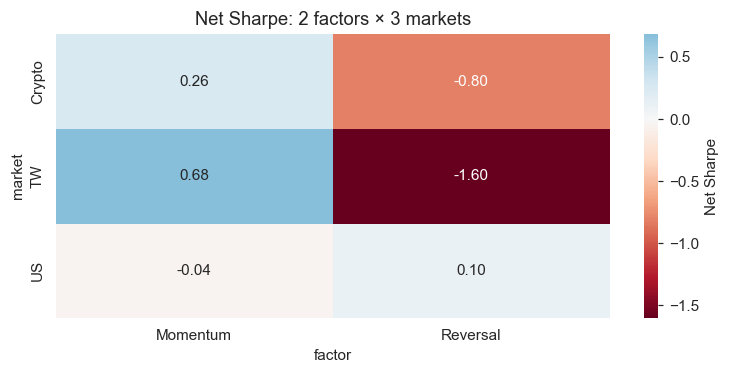

In [4]:
sharpe_matrix = perf["sharpe"].unstack("factor")
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(sharpe_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0,
            ax=ax, cbar_kws={"label": "Net Sharpe"})
ax.set_title("Net Sharpe: 2 factors × 3 markets")
plt.tight_layout()
plt.savefig("../reports/figures/99_sharpe_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. Factor independence — return correlation within each market

If momentum and reversal are truly capturing different information, their
daily return series within the same market should be close to uncorrelated
(or mildly negative, since they bet on opposite horizons).

In [5]:
corrs = []
for m in ["US", "TW", "Crypto"]:
    mom = returns_df[(m, "Momentum")].dropna()
    rev = returns_df[(m, "Reversal")].dropna()
    common = mom.index.intersection(rev.index)
    corrs.append({
        "market": m,
        "corr":   mom.loc[common].corr(rev.loc[common]),
        "n_days": len(common),
    })
corr_tbl = pd.DataFrame(corrs).set_index("market")
corr_tbl.round(3)

,corr,n_days
market,,
US,0.015,2659
TW,-0.022,2572
Crypto,0.115,2905


## 4. Combined portfolio (50/50 momentum + reversal)

Within each market, hold the momentum strategy and reversal strategy at
equal dollar weight. If they are independent and both have positive
expected return, diversification should improve Sharpe.

In [6]:
combined_rows = []
for m in ["US", "TW", "Crypto"]:
    mom = returns_df[(m, "Momentum")].dropna()
    rev = returns_df[(m, "Reversal")].dropna()
    common = mom.index.intersection(rev.index)
    combined = 0.5 * mom.loc[common] + 0.5 * rev.loc[common]
    combined_rows.append({
        "market":           m,
        "mom_sharpe":       sharpe(mom.loc[common]),
        "rev_sharpe":       sharpe(rev.loc[common]),
        "combined_sharpe":  sharpe(combined),
        "combined_ann_ret": annualized_return(combined),
        "combined_mdd":     max_drawdown(combined),
    })
combined_tbl = pd.DataFrame(combined_rows).set_index("market")
combined_tbl.round(3)

,mom_sharpe,rev_sharpe,combined_sharpe,combined_ann_ret,combined_mdd
market,,,,,
US,-0.043,0.096,0.034,-0.004,-0.287
TW,0.683,-1.602,-0.685,-0.102,-0.667
Crypto,0.258,-0.800,-0.447,-0.303,-0.993


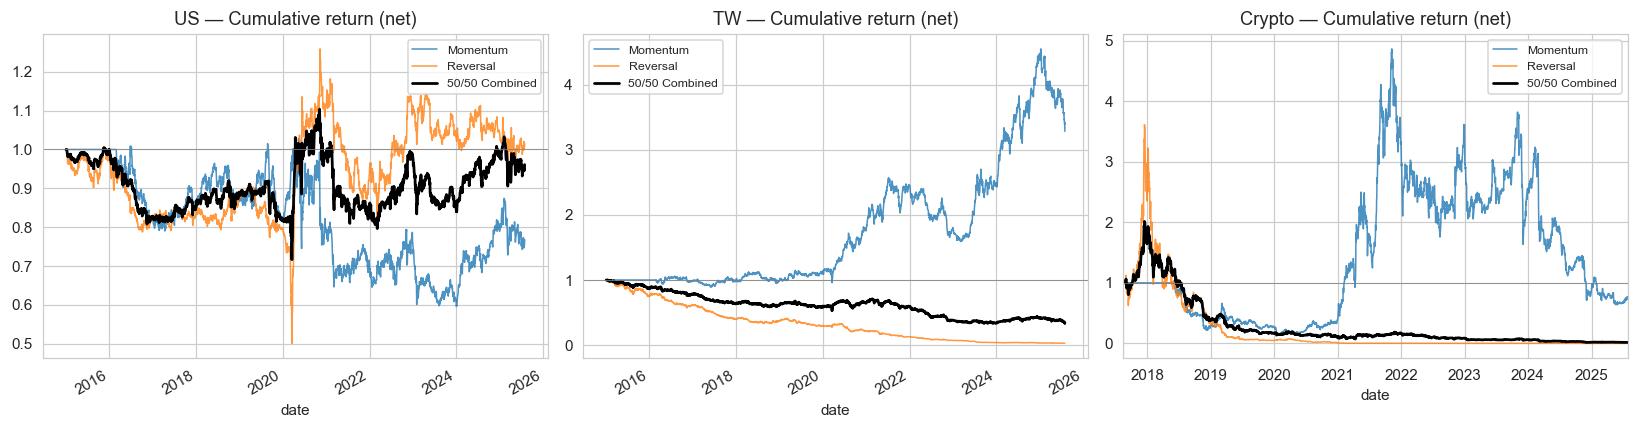

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, m in zip(axes, ["US", "TW", "Crypto"]):
    mom = returns_df[(m, "Momentum")].dropna()
    rev = returns_df[(m, "Reversal")].dropna()
    common = mom.index.intersection(rev.index)
    combined = 0.5 * mom.loc[common] + 0.5 * rev.loc[common]
    (1 + mom.loc[common]).cumprod().plot(ax=ax, label="Momentum", linewidth=1.0, alpha=0.8)
    (1 + rev.loc[common]).cumprod().plot(ax=ax, label="Reversal", linewidth=1.0, alpha=0.8)
    (1 + combined).cumprod().plot(ax=ax, label="50/50 Combined", linewidth=1.8, color="black")
    ax.axhline(1, color="gray", lw=0.5)
    ax.set_title(f"{m} — Cumulative return (net)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/99_combined.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Rolling 1-year Sharpe

The stability of a strategy matters as much as the full-period average.
A factor that yields +1.0 overall but flips between +3 and −2 year-to-year
is essentially noise. Rolling 252-day Sharpe reveals regime stability.

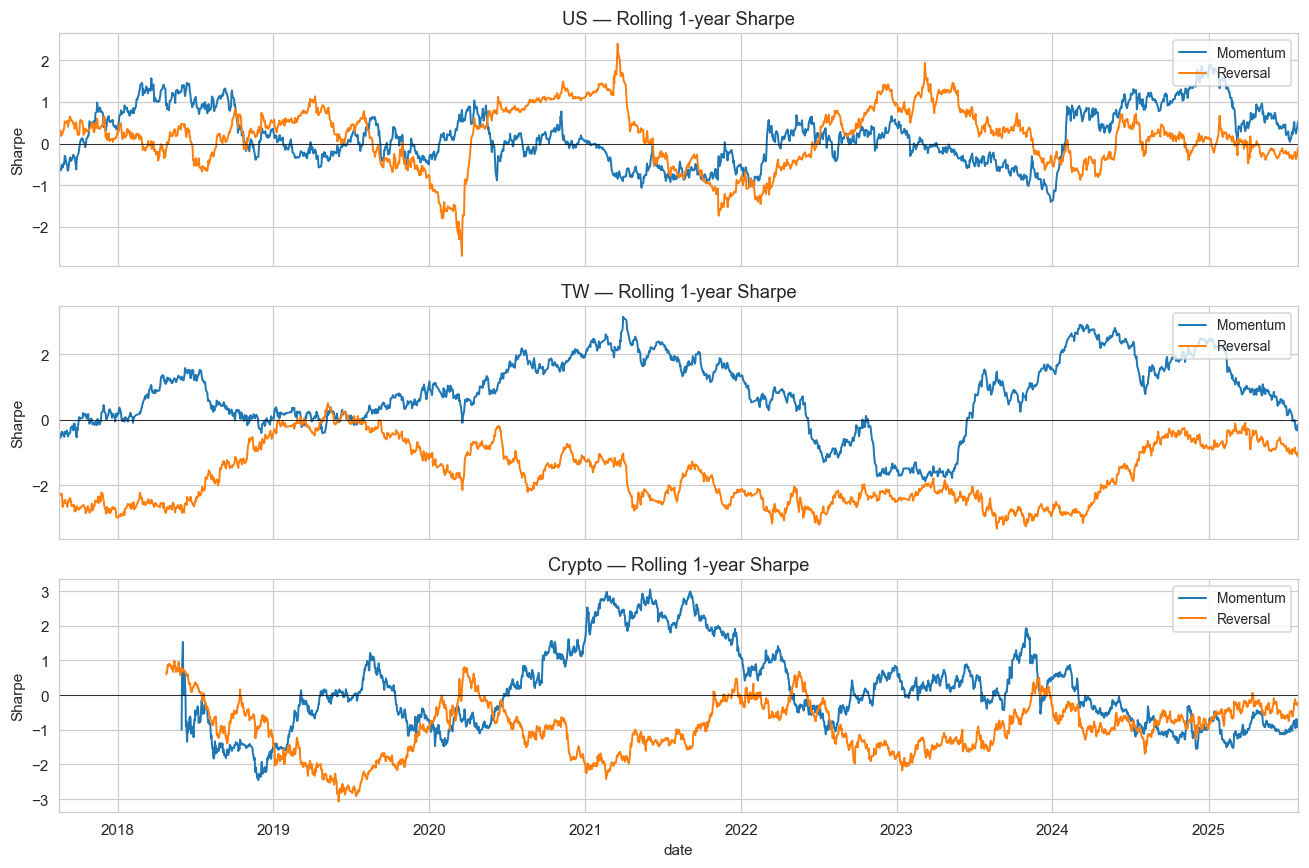

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
window = 252

for ax, m in zip(axes, ["US", "TW", "Crypto"]):
    for f in ["Momentum", "Reversal"]:
        r = returns_df[(m, f)].dropna()
        rolling = r.rolling(window).mean() / r.rolling(window).std() * np.sqrt(252)
        rolling.plot(ax=ax, label=f, linewidth=1.3)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(f"{m} — Rolling 1-year Sharpe")
    ax.set_ylabel("Sharpe")
    ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/99_rolling_sharpe.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. The scorecard

Summarise what each (factor, market) cell actually teaches us.

In [9]:
# Rank every cell by Sharpe, annotate with narrative tag
def verdict(row):
    s = row["sharpe"]
    if s >= 0.5:
        return "TRADEABLE"
    if s >= 0.2:
        return "marginal (survives costs but fragile)"
    if s >= -0.2:
        return "NULL (costs eat alpha)"
    return "TOXIC (net loser)"

scorecard = perf.copy()
scorecard["verdict"] = scorecard.apply(verdict, axis=1)
scorecard[["sharpe", "ann_ret", "max_dd", "verdict"]].round(3)

sharpe  ann_ret  max_dd  \
market factor                              
Crypto Momentum   0.258   -0.026  -0.869   
       Reversal  -0.800   -0.600  -1.000   
TW     Momentum   0.683    0.124  -0.380   
       Reversal  -1.602   -0.297  -0.973   
US     Momentum  -0.043   -0.025  -0.420   
       Reversal   0.096    0.001  -0.503   

                                               verdict  
market factor                                           
Crypto Momentum  marginal (survives costs but fragile)  
       Reversal                      TOXIC (net loser)  
TW     Momentum                              TRADEABLE  
       Reversal                      TOXIC (net loser)  
US     Momentum                 NULL (costs eat alpha)  
       Reversal                 NULL (costs eat alpha)

## 7. Bottom line

- **Best cell in the matrix**: TW × Momentum at +0.68 net Sharpe. Likely
  driven by retail-heavy participation and weaker institutional
  arbitrage than US large caps.
- **Worst cell**: TW × Reversal at −1.60 net Sharpe — the 0.3%
  transaction tax on every sell, compounded weekly, is the killer.
- **Factor × market interaction**: within each market momentum and
  reversal returns are near-uncorrelated (|ρ| < 0.1), so they capture
  different horizons cleanly; the cost structure is what differentiates
  which cell is actually tradeable.
- **Combined portfolio verdict**: 50/50 blends are weighted averages of
  Sharpe and do **not** help, because one leg is usually negative and
  drags down the winner.
- **Investability**: after realistic costs, only one of the six cells —
  TW Momentum — is clearly worth deploying capital to. Everything else
  is marginal at best.